## Decission tree algorithm  
-Autor: Addán Isaí Cruz Cruz  
-Date: 30/09/2025  
-Description: Perform a complete analisys from public health data and predict if a person will have diabetes or not


In [32]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [4]:
#Load data
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv'
df_raw = pd.read_csv(url)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df_raw.sample(10, random_state=2025)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
82,7,83,78,26,71,29.3,0.767,36,0
152,9,156,86,28,155,34.3,1.189,42,1
393,4,116,72,12,87,22.1,0.463,37,0
691,13,158,114,0,0,42.3,0.257,44,1
14,5,166,72,19,175,25.8,0.587,51,1
542,10,90,85,32,0,34.9,0.825,56,1
749,6,162,62,0,0,24.3,0.178,50,1
629,4,94,65,22,0,24.7,0.148,21,0
724,1,111,94,0,0,32.8,0.265,45,0
222,7,119,0,0,0,25.2,0.209,37,0


## Note  
-Outcome: indicates high risk (1:High risk, 0:Normal)

In [17]:
#Preprocessing
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.lower()
df_baking['outcome'] = df_baking['outcome'].astype('category')
df = df_baking.copy()

In [18]:
#EDA
df_train, df_test = train_test_split(df, test_size=0.1, random_state=2025)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.shape, df_test.shape

((691, 9), (77, 9))

In [19]:
display(df_train.describe(include='number').T)


,count,mean,std,min,25%,50%,75%,max
pregnancies,691.0,3.803184,3.374936,0.000,1.0000,3.000,6.0000,17.00
glucose,691.0,121.027496,31.185524,0.000,99.5000,117.000,140.0000,199.00
bloodpressure,691.0,69.306802,18.310722,0.000,64.0000,72.000,80.0000,122.00
skinthickness,691.0,21.023155,16.019627,0.000,0.0000,23.000,33.0000,99.00
insulin,691.0,82.397974,117.504817,0.000,0.0000,41.000,130.0000,846.00
bmi,691.0,32.051809,7.704998,0.000,27.4000,32.000,36.6000,67.10
diabetespedigreefunction,691.0,0.475427,0.337236,0.078,0.2405,0.378,0.6295,2.42
age,691.0,32.777135,11.500452,21.000,24.0000,29.000,40.0000,81.00


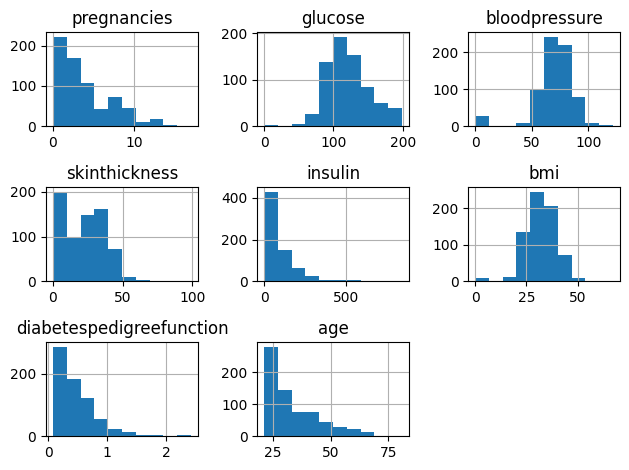

In [20]:
df_train.hist()
plt.tight_layout()
plt.show()

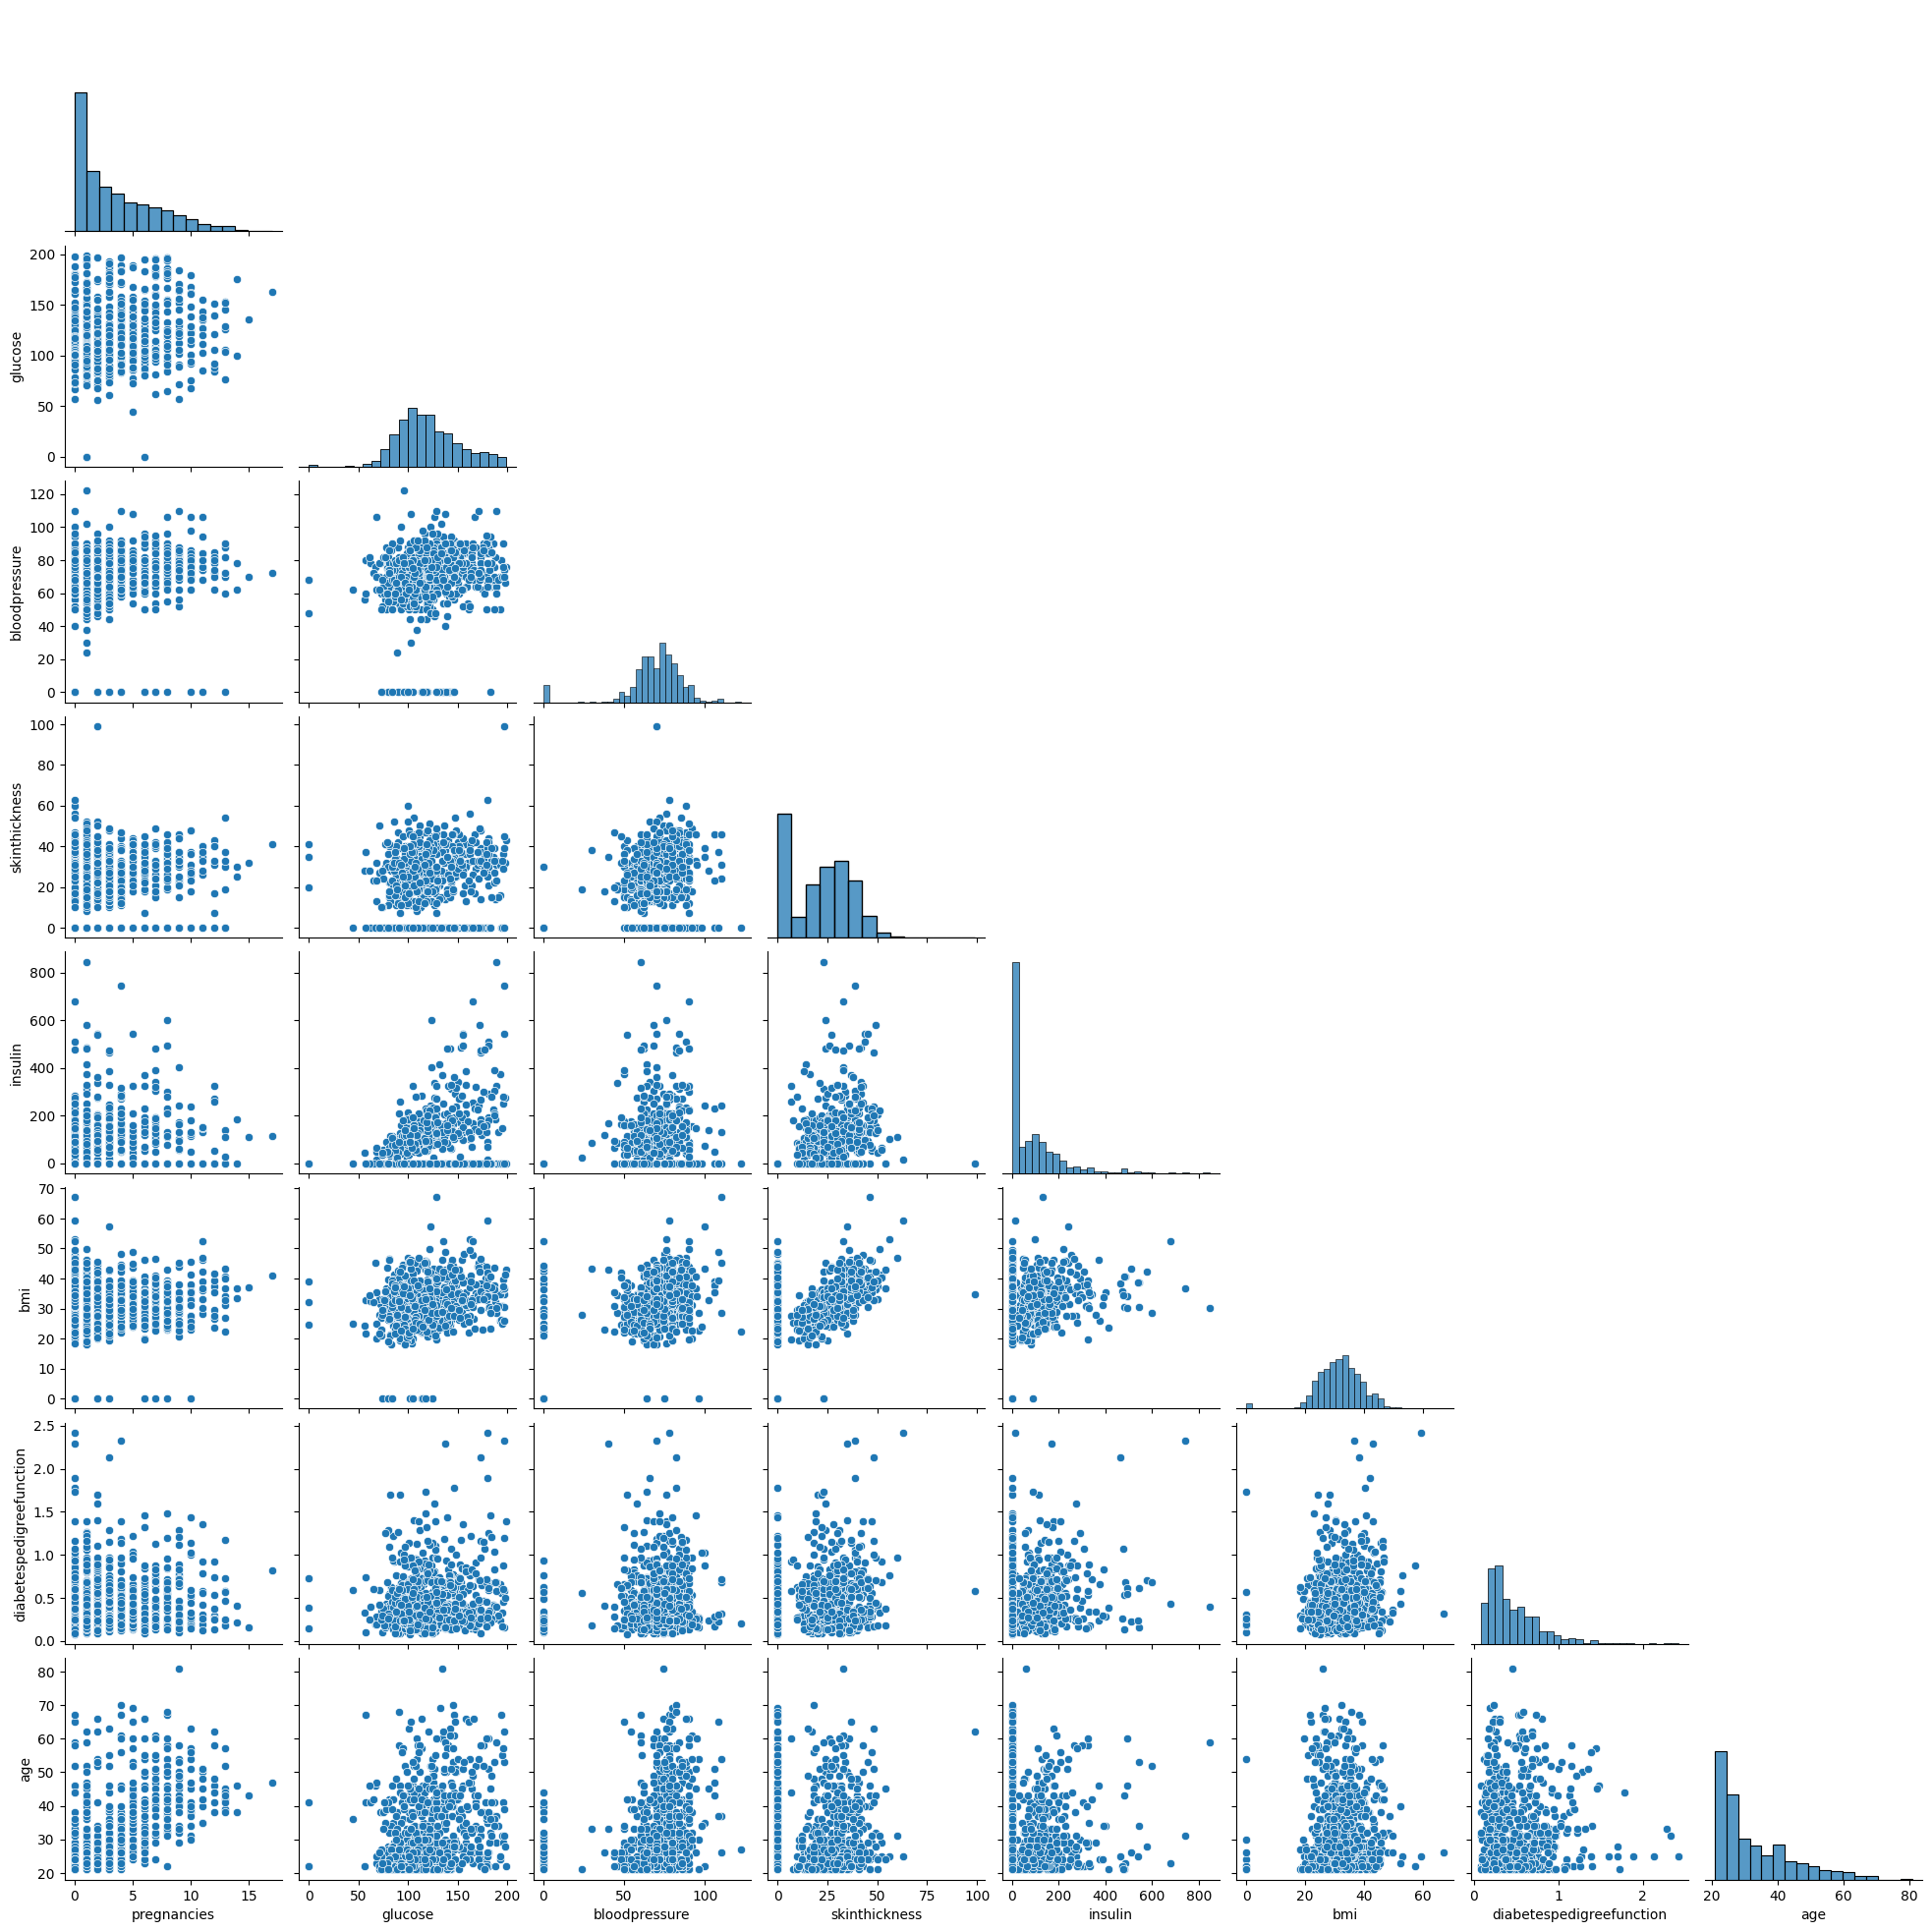

In [21]:
sns.pairplot(data=df_train, corner=True)
plt.show()

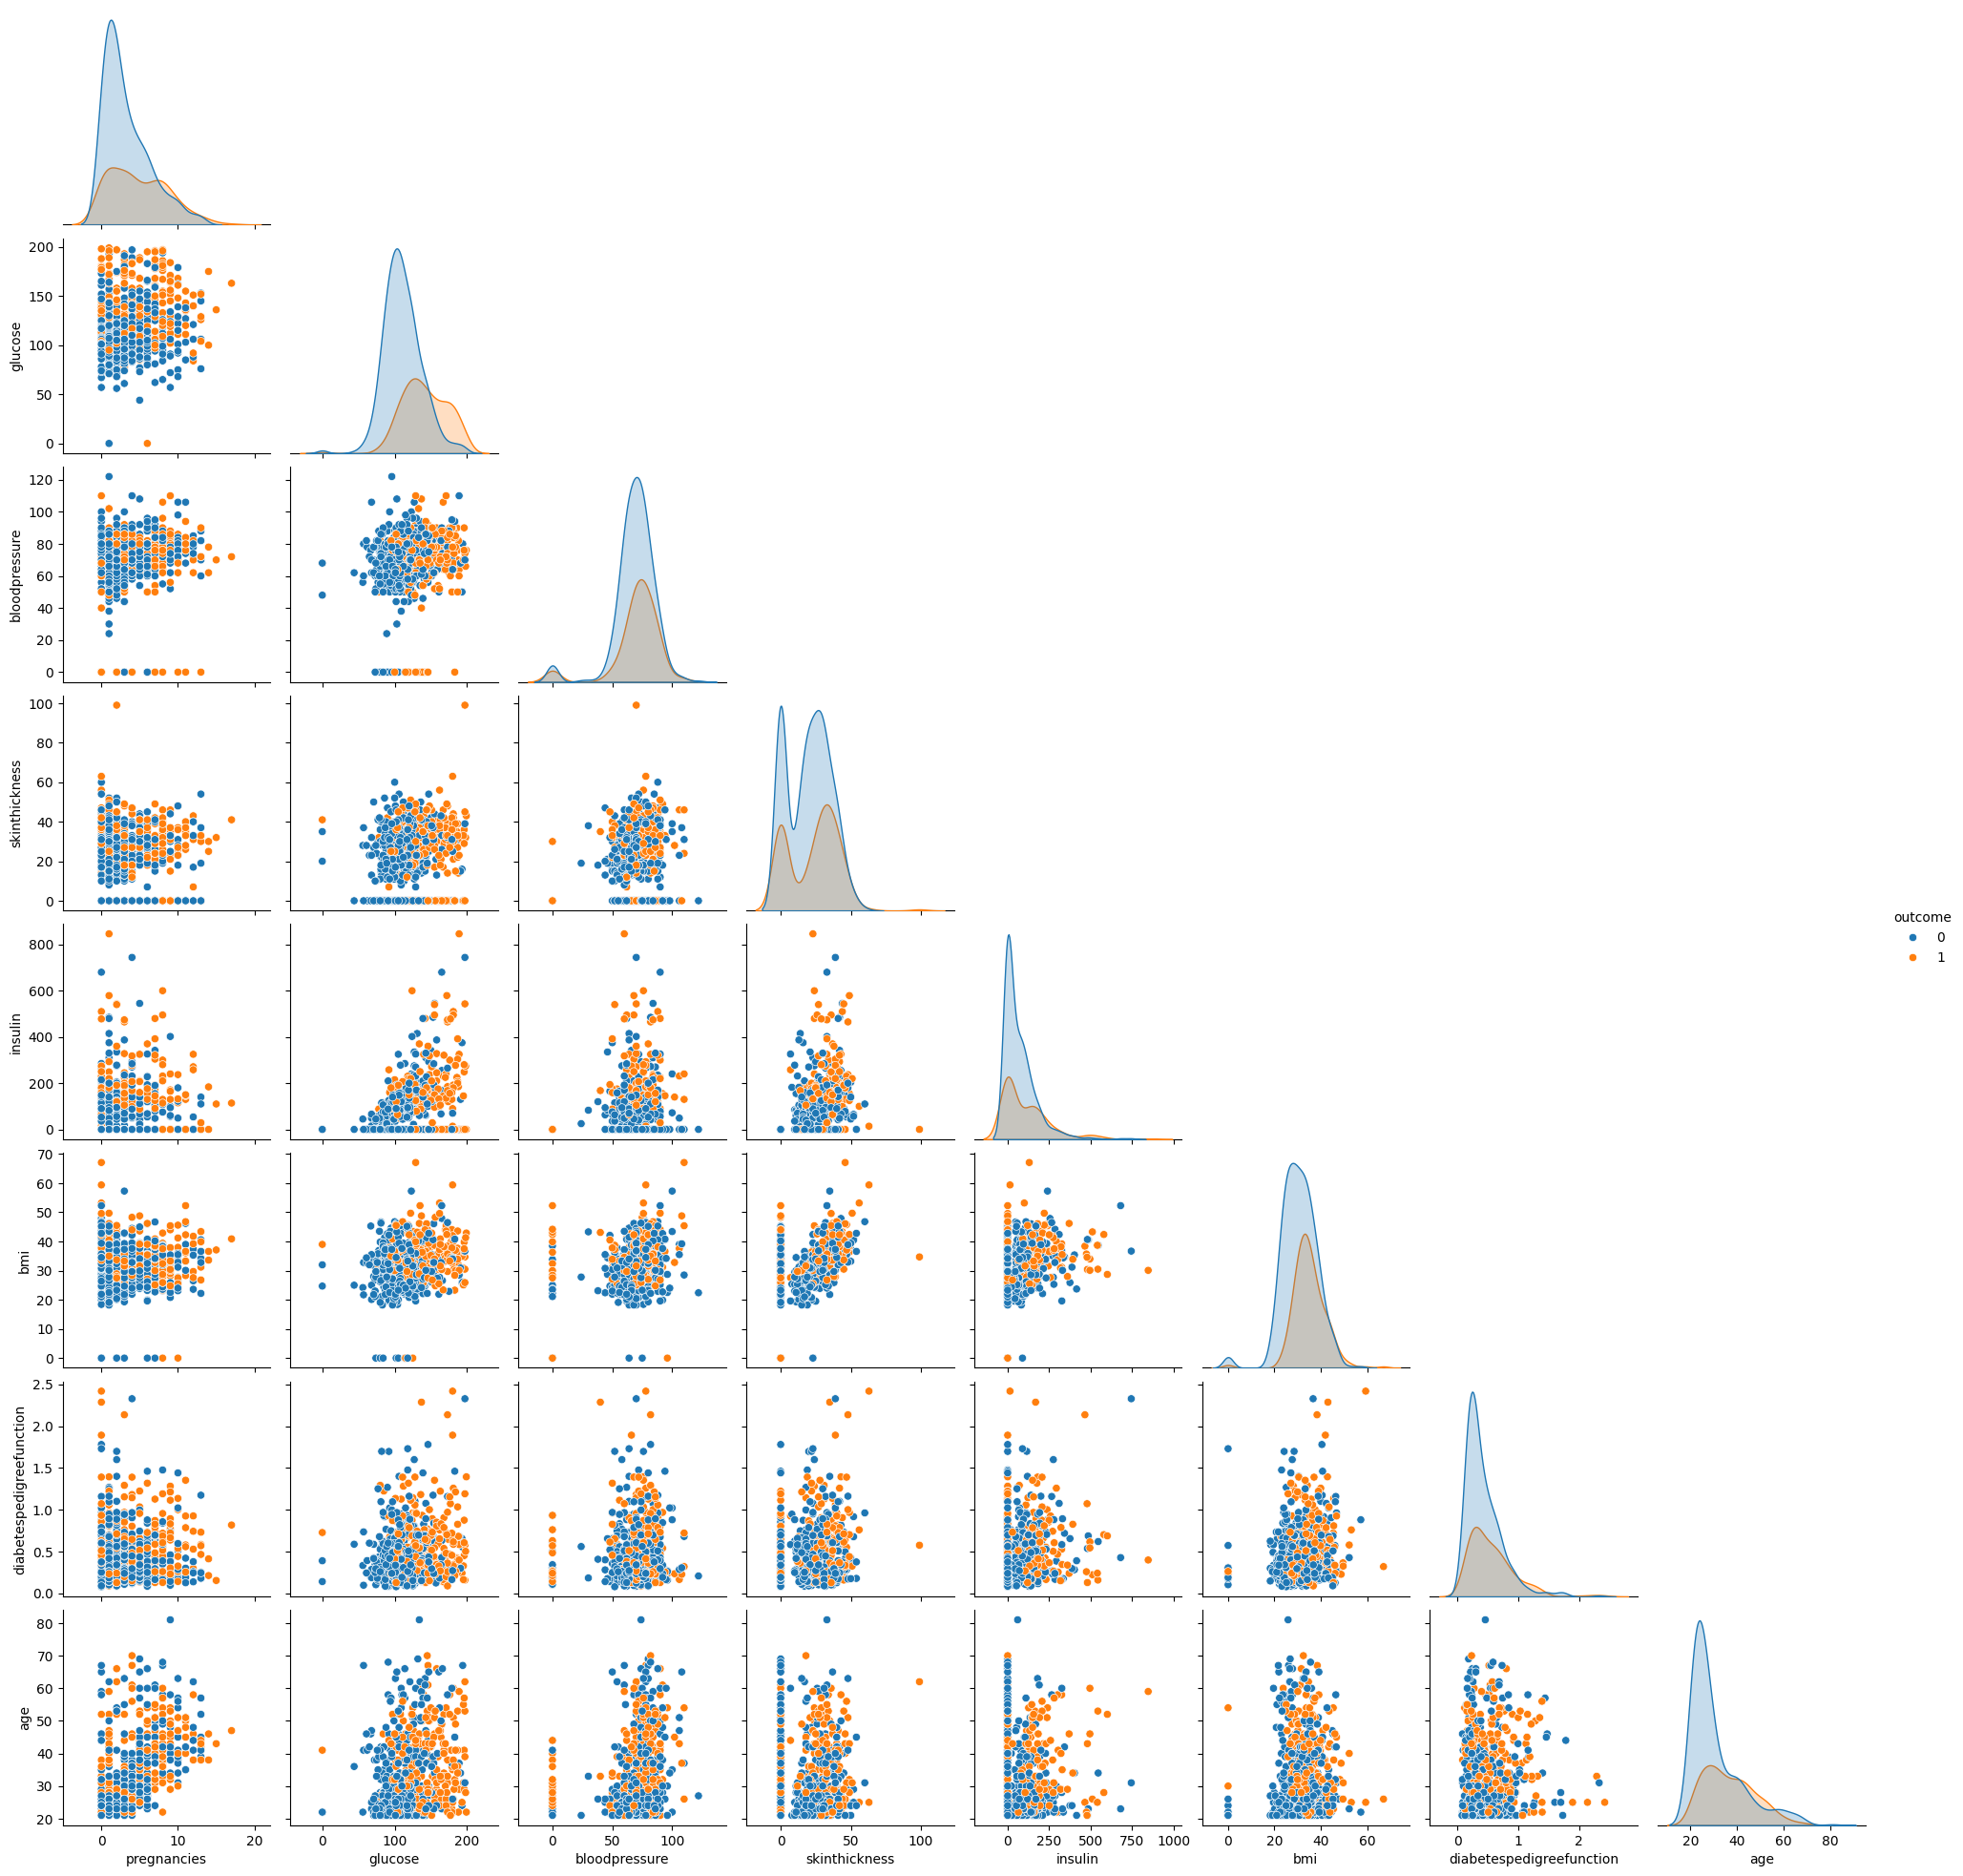

In [22]:
sns.pairplot(data=df_train, hue='outcome', corner=True)
plt.show()

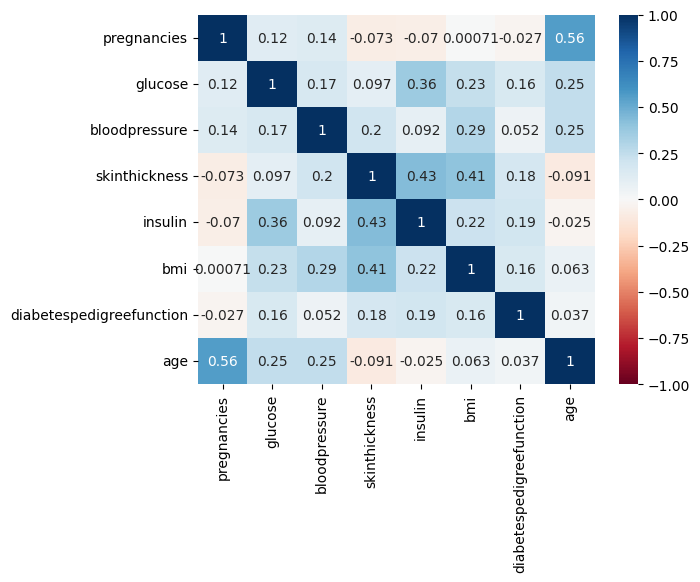

In [23]:
sns.heatmap(df_train.select_dtypes('number').corr(), vmin=-1, vmax=1, cmap='RdBu', annot=True)
plt.show()

In [29]:
#ML
X_train = df_train.drop(columns='outcome')
y_train = df_train['outcome']

X_test = df_test.drop(columns='outcome')
y_test = df_test['outcome']

encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)



In [30]:
tree_clf = DecisionTreeClassifier(class_weight='balanced', random_state=2025)
tree_clf.fit(X_train,y_train_enc)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [31]:
y_hat = tree_clf.predict(X_test)
print(f'Accuracy score: {accuracy_score(y_test_enc, y_hat)}')

Accuracy score: 0.7402597402597403


In [33]:
tree_clf_cv = GridSearchCV(
    tree_clf,
    param_grid = {
        'max_depth':[1,2,3,4,5,6,7],
        'min_samples_leaf':[1,2,4,6],
    },
    cv = 5,
    scoring = 'accuracy'

)

In [34]:
tree_clf_cv.fit(X_train, y_train_enc)
tree_clf_cv.best_params_

{'max_depth': 7, 'min_samples_leaf': 1}

In [35]:
tree_clf = DecisionTreeClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=1, random_state=2025)
tree_clf.fit(X_train,y_train_enc)

,criterion,'gini'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [36]:
y_hat = tree_clf.predict(X_test)
print(f'Accuracy score: {accuracy_score(y_test_enc, y_hat)}')

Accuracy score: 0.7662337662337663
